In [1]:
import re
from pathlib import Path

import pandas as pd

# ----------------------------
# 1) Load source workbook
# ----------------------------
excel_path = Path("../data/Clarkston_HH_by_age.xlsx")
sheet_name = "Export041026"

df_raw = pd.read_excel(excel_path, sheet_name=sheet_name)

# ----------------------------
# 2) Keep only HH age columns for 2025/2030 and 2m/5m
#    Example header: "2025 HH Age 15-24(2m)"
# ----------------------------
age_col_pattern = re.compile(r"^(\d{4})\s+HH\s+Age\s+(.+?)\((\d+m)\)$")

records = []
for col in df_raw.columns:
    m = age_col_pattern.match(col)
    if not m:
        continue

    year, age_bin, radius = m.groups()
    tmp = pd.DataFrame({
        "age_bin": age_bin,
        "radius": radius,
        "year": int(year),
        "value": pd.to_numeric(df_raw[col], errors="coerce"),
    })
    records.append(tmp)

if not records:
    raise ValueError("No age distribution columns matched expected naming pattern.")

long_df = pd.concat(records, ignore_index=True)

# ----------------------------
# 3) Aggregate and reshape
#    Rows: age bins
#    Columns: radius -> year (multi-level)
# ----------------------------
age_order = ["15-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84", "85+"]
radius_order = ["2m", "5m"]
year_order = [2025, 2030]

summary = (
    long_df.groupby(["age_bin", "radius", "year"], as_index=False)["value"]
    .sum()
)

summary["age_bin"] = pd.Categorical(summary["age_bin"], categories=age_order, ordered=True)
summary["radius"] = pd.Categorical(summary["radius"], categories=radius_order, ordered=True)
summary["year"] = pd.Categorical(summary["year"], categories=year_order, ordered=True)

formatted = (
    summary.pivot(index="age_bin", columns=["radius", "year"], values="value")
    .sort_index()
    .sort_index(axis=1, level=[0, 1])
)

formatted = formatted.rename_axis(index="Householder Age Bin", columns=["Radius", "Year"])

# ----------------------------
# 3b) Interpolated household counts: 2025–2030 (linear from 2025 → 2030)
# annual_delta = (HH_2030 - HH_2025) / 5; HH_year = HH_2025 + annual_delta * (year - 2025)
# So 2030 matches the source 2030 column exactly and 2025 matches the source 2025 column.
# ----------------------------
interp_years = [2025, 2026, 2027, 2028, 2029, 2030]
interp_blocks = []
for r in radius_order:
    hh_2025 = formatted[(r, 2025)]
    hh_2030 = formatted[(r, 2030)]
    annual_delta = (hh_2030 - hh_2025) / 5.0
    part = pd.DataFrame(
        {y: hh_2025 + annual_delta * (y - 2025) for y in interp_years},
        index=formatted.index,
    )
    part.columns = pd.MultiIndex.from_product([[r], part.columns], names=["Radius", "Year"])
    interp_blocks.append(part)

df = pd.concat(interp_blocks, axis=1)
df = df.round(0).astype(int)

# Optional: format display with commas for readability
formatted_display = formatted.map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

print("Reformatted household age distribution (aggregated):")
formatted_display

df_display = df.map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
print("\nInterpolated household counts by age bin, 2025–2030 (linear from 2025→2030):")
df_display

# Optional: save a flat-file version for sharing
output_path = Path("../data/Clarkston_HH_by_age_reformatted.csv")
formatted.to_csv(output_path)
print(f"Saved numeric table to: {output_path}")

Reformatted household age distribution (aggregated):

Interpolated household counts by age bin, 2025–2030 (linear from 2025→2030):
Saved numeric table to: ../data/Clarkston_HH_by_age_reformatted.csv


In [2]:
#print head for formatted
df.head(10)

Radius                   2m                                               5m  \
Year                   2025    2026    2027    2028    2029    2030     2025   
Householder Age Bin                                                            
15-24                 66409   66734   67059   67384   67709   68034   326306   
25-34                278036  271037  264038  257040  250041  243042  1429130   
35-44                347514  343797  340080  336362  332645  328928  1713337   
45-54                294960  298669  302377  306086  309794  313503  1529830   
55-64                262258  263102  263946  264791  265635  266479  1458121   
65-74                208395  210890  213385  215879  218374  220869  1255777   
75-84                111918  116794  121671  126547  131424  136300   740191   
85+                   32170   35526   38882   42238   45594   48950   240607   

Radius                                                            
Year                    2026     2027     2028     2029     2030  
Householder Age Bin                                               
15-24                 326156   326005   325855   325704   325554  
25-34                1392848  1356566  1320285  1284003  1247721  
35-44                1707282  1701227  1695172  1689117  1683062  
45-54                1547009  1564189  1581368  1598548  1615727  
55-64                1458115  1458109  1458103  1458097  1458091  
65-74                1263722  1271667  1279613  1287558  1295503  
75-84                 766195   792200   818204   844209   870213  
85+                   261115   281623   302132   322640   343148

In [3]:
import re
from pathlib import Path

import pandas as pd

# ----------------------------
# 1) Load source workbook
# ----------------------------
excel_path = Path("../data/Residential/CostarExport (13).xlsx")
sheet_name = "Export041026"

df_raw = pd.read_excel(excel_path, sheet_name=sheet_name)

# ----------------------------
# 2) Keep only HH age columns for 2025/2030 and 2m/5m
#    Example header: "2025 HH Age 15-24(2m)"
# ----------------------------
age_col_pattern = re.compile(r"^(\d{4})\s+HH\s+Age\s+(.+?)\((\d+m)\)$")

records = []
for col in df_raw.columns:
    m = age_col_pattern.match(col)
    if not m:
        continue

    year, age_bin, radius = m.groups()
    tmp = pd.DataFrame({
        "age_bin": age_bin,
        "radius": radius,
        "year": int(year),
        "value": pd.to_numeric(df_raw[col], errors="coerce"),
    })
    records.append(tmp)

if not records:
    raise ValueError("No age distribution columns matched expected naming pattern.")

long_df = pd.concat(records, ignore_index=True)

# ----------------------------
# 3) Aggregate and reshape
#    Rows: age bins
#    Columns: radius -> year (multi-level)
# ----------------------------
age_order = ["15-24", "25-34", "35-44", "45-54", "55-64", "65-74", "75-84", "85+"]
radius_order = ["2m", "5m"]
year_order = [2025, 2030]

summary = (
    long_df.groupby(["age_bin", "radius", "year"], as_index=False)["value"]
    .sum()
)

summary["age_bin"] = pd.Categorical(summary["age_bin"], categories=age_order, ordered=True)
summary["radius"] = pd.Categorical(summary["radius"], categories=radius_order, ordered=True)
summary["year"] = pd.Categorical(summary["year"], categories=year_order, ordered=True)

formatted = (
    summary.pivot(index="age_bin", columns=["radius", "year"], values="value")
    .sort_index()
    .sort_index(axis=1, level=[0, 1])
)

formatted = formatted.rename_axis(index="Householder Age Bin", columns=["Radius", "Year"])

# ----------------------------
# 3b) Interpolated household counts: 2025–2030 (linear from 2025 → 2030)
# annual_delta = (HH_2030 - HH_2025) / 5; HH_year = HH_2025 + annual_delta * (year - 2025)
# So 2030 matches the source 2030 column exactly and 2025 matches the source 2025 column.
# ----------------------------
interp_years = [2025, 2026, 2027, 2028, 2029, 2030]
interp_blocks = []
for r in radius_order:
    hh_2025 = formatted[(r, 2025)]
    hh_2030 = formatted[(r, 2030)]
    annual_delta = (hh_2030 - hh_2025) / 5.0
    part = pd.DataFrame(
        {y: hh_2025 + annual_delta * (y - 2025) for y in interp_years},
        index=formatted.index,
    )
    part.columns = pd.MultiIndex.from_product([[r], part.columns], names=["Radius", "Year"])
    interp_blocks.append(part)

df = pd.concat(interp_blocks, axis=1)
df = df.round(0).astype(int)

# Optional: format display with commas for readability
formatted_display = formatted.map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")

print("Reformatted household age distribution (aggregated):")
formatted_display

df_display = df.map(lambda x: f"{x:,.0f}" if pd.notna(x) else "")
print("\nInterpolated household counts by age bin, 2025–2030 (linear from 2025→2030):")
df_display

# Optional: save a flat-file version for sharing
output_path = Path("../data/Clarkston_HH_by_age_reformatted.csv")
formatted.to_csv(output_path)
print(f"Saved numeric table to: {output_path}")

Reformatted household age distribution (aggregated):

Interpolated household counts by age bin, 2025–2030 (linear from 2025→2030):
Saved numeric table to: ../data/Clarkston_HH_by_age_reformatted.csv


In [4]:
df

Radius                    2m                                               \
Year                    2025     2026     2027     2028     2029     2030   
Householder Age Bin                                                         
15-24                 309441   309852   310262   310673   311083   311494   
25-34                1373504  1337646  1301789  1265931  1230074  1194216   
35-44                1697143  1687734  1678325  1668916  1659507  1650098   
45-54                1527839  1544734  1561629  1578525  1595420  1612315   
55-64                1391451  1398883  1406315  1413746  1421178  1428610   
65-74                1173482  1183774  1194066  1204358  1214650  1224942   
75-84                 703604   727623   751642   775660   799679   823698   
85+                   226547   246527   266506   286486   306465   326445   

Radius                     5m                                          \
Year                     2025      2026      2027      2028      2029   
Householder Age Bin                                                     
15-24                 1877939   1869874   1861809   1853745   1845680   
25-34                 9610875   9254036   8897198   8540359   8183521   
35-44                11413879  11402717  11391555  11380393  11369231   
45-54                 9399944   9598209   9796474   9994740  10193005   
55-64                 8400448   8463280   8526112   8588944   8651776   
65-74                 6997200   7069073   7140946   7212818   7284691   
75-84                 4150553   4296293   4442033   4587772   4733512   
85+                   1325279   1443339   1561398   1679458   1797517   

Radius                         
Year                     2030  
Householder Age Bin            
15-24                 1837615  
25-34                 7826682  
35-44                11358069  
45-54                10391270  
55-64                 8714608  
65-74                 7356564  
75-84                 4879252  
85+                   1915577

In [5]:
# ----------------------------
# 4) Build tenure table (Renters and Owners) by age bin
#    using reference-person-age-ranges-2024.xlsx only
# ----------------------------
ref_path = Path("../data/reference-person-age-ranges-2024.xlsx")
ref_raw = pd.read_excel(ref_path, sheet_name="Table 1300", header=None)

# Header row with age groups is row index 2 in this file.
header_values = ref_raw.iloc[2].tolist()
clean_cols = []
for i, val in enumerate(header_values):
    if i == 0:
        clean_cols.append("Item")
    else:
        clean_cols.append(str(val).replace("\n", " ").strip())

ref = ref_raw.copy()
ref.columns = clean_cols

owner_row = ref[ref["Item"].astype(str).str.strip().str.lower() == "homeowner"]
renter_row = ref[ref["Item"].astype(str).str.strip().str.lower() == "renter"]
if owner_row.empty or renter_row.empty:
    raise ValueError("Could not find 'Homeowner' and/or 'Renter' rows in reference table.")

owner_row = owner_row.iloc[0]
renter_row = renter_row.iloc[0]

# Map source age columns to householder bins.
# Note: source has only "75 years and older", so it is used for both 75-84 and 85+.
age_to_ref_col = {
    "15-24": "Under 25 years",
    "25-34": "25-34 years",
    "35-44": "35-44 years",
    "45-54": "45-54 years",
    "55-64": "55-64 years",
    "65-74": "65-74 years",
    "75-84": "75 years and older",
    "85+": "75 years and older",
}

tenure_table = pd.DataFrame(
    {
        "Renters": {
            age_bin: pd.to_numeric(renter_row[ref_col], errors="coerce")
            for age_bin, ref_col in age_to_ref_col.items()
        },
        "Owners": {
            age_bin: pd.to_numeric(owner_row[ref_col], errors="coerce")
            for age_bin, ref_col in age_to_ref_col.items()
        },
    }
)

tenure_table.index.name = "Householder Age Bin"
tenure_table = tenure_table.reindex(age_order)

tenure_table_display = tenure_table.map(lambda x: f"{x:.1f}%" if pd.notna(x) else "")

print("Percent of renters and owners by householder age bin (reference 2024):")
tenure_table_display

Percent of renters and owners by householder age bin (reference 2024):


/Users/elyas/Applications/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Renters,Owners
Householder Age Bin,,
15-24,90.0%,10.0%
25-34,56.0%,44.0%
35-44,40.0%,60.0%
45-54,30.0%,70.0%
55-64,24.0%,76.0%
65-74,21.0%,79.0%
75-84,23.0%,77.0%
85+,23.0%,77.0%


In [6]:
# Demand table: 2026 base, growth 2026→2029, tenure from numeric tenure_table

demand_age_bins = [
    "Under 25",
    "25-34",
    "35-54",
    "55-64",
    "65-74",
    "75+",
]

radius = "2m"  # change to "5m" if needed

def hh_bin_counts(ring, year):
    """Household counts by demand bin from interpolated `df`."""
    s = df[(ring, year)]
    return {
        "Under 25": int(s.loc["15-24"]),
        "25-34": int(s.loc["25-34"]),
        "35-54": int(s.loc["35-44"] + s.loc["45-54"]),
        "55-64": int(s.loc["55-64"]),
        "65-74": int(s.loc["65-74"]),
        "75+": int(s.loc["75-84"] + s.loc["85+"]),
    }

demand_counts_2026 = hh_bin_counts(radius, 2026)
demand_counts_2029 = hh_bin_counts(radius, 2029)

# Annualized household growth: (2029 - 2026) / 3
growth_counts = {
    b: (demand_counts_2029[b] - demand_counts_2026[b]) / 3.0 for b in demand_age_bins
}

demand_2026_rounded = {k: int(round(v, 0)) for k, v in demand_counts_2026.items()}
growth_counts_rounded = {k: int(round(v, 0)) for k, v in growth_counts.items()}

# Use numeric renters % (0–100), not the formatted display frame
tenure_renters = tenure_table["Renters"].astype(float)

def mean_of_bins(bins):
    return float(sum(tenure_renters[b] for b in bins)) / len(bins)

percent_renters = {
    "Under 25": float(tenure_renters["15-24"]),
    "25-34": float(tenure_renters["25-34"]),
    # Match HH bin: only 35-44 and 45-54 (unweighted mean of their renter shares)
    "35-54": mean_of_bins(["35-44", "45-54"]),
    "55-64": float(tenure_renters["55-64"]),
    "65-74": float(tenure_renters["65-74"]),
    "75+": mean_of_bins(["75-84", "85+"]),
}

total_renters_rounded = {
    k: int(round(demand_2026_rounded[k] * percent_renters[k] / 100.0, 0))
    for k in demand_age_bins
}

lease_turnover_rounded = {
    k: int(round(total_renters_rounded[k] * 0.4, 0)) for k in demand_age_bins
}

rental_demand = {
    k: lease_turnover_rounded[k] + growth_counts_rounded[k] for k in demand_age_bins
}

demand_rows = [
    demand_2026_rounded,
    {k: percent_renters[k] for k in demand_age_bins},
    total_renters_rounded,
    lease_turnover_rounded,
    growth_counts_rounded,
    rental_demand,
]
demand_index = [
    "Total households",
    "% Renters",
    "Total Renters",
    "Movers (40% Turnover)",
    "New household growth (annualized)",
    "Rental Demand",
]

demand = pd.DataFrame(demand_rows, index=demand_index)
demand = demand[demand_age_bins]

def format_with_commas_or_percent(val, row_idx):
    if pd.isnull(val):
        return ""
    if row_idx == "% Renters":
        return f"{val:.1f}%"
    return f"{val:,.0f}"

demand_display = demand.copy()
for idx in demand_display.index:
    demand_display.loc[idx] = [
        format_with_commas_or_percent(val, idx) for val in demand_display.loc[idx]
    ]

print("Demand table (2026 HH, % renters, movers, growth, rental demand):")
display(demand_display)

Demand table (2026 HH, % renters, movers, growth, rental demand):


/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/263765672.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '309,852' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_display.loc[idx] = [
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/263765672.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1,337,646' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_display.loc[idx] = [
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/263765672.py:95: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '3,232,468' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_dis

,Under 25,25-34,35-54,55-64,65-74,75+
Total households,"309,852","1,337,646","3,232,468","1,398,883","1,183,774","974,150"
% Renters,90.0%,56.0%,35.0%,24.0%,21.0%,23.0%
Total Renters,"278,867","749,082","1,131,364","335,732","248,593","224,054"
Movers (40% Turnover),"111,547","299,633","452,546","134,293","99,437","89,622"
New household growth (annualized),410,"-35,857","7,486","7,432","10,292","43,998"
Rental Demand,"111,957","263,776","460,032","141,725","109,729","133,620"


In [7]:
# Demand table: base year 2029; columns = each age bin × (2m | 5m)

demand_age_bins = [
    "Under 25",
    "25-34",
    "35-54",
    "65-74",
    "75+",
]

radii = ["2m", "5m"]
base_year = 2029
growth_end_year = 2030  # annual step: (2030 - 2029) / 1

def demand_hh_counts_for_year(radius: str, year: int) -> dict:
    s = df[(radius, year)]
    return {
        "Under 25": int(s.loc["15-24"]),
        "25-34": int(s.loc["25-34"]),
        "35-54": int(s.loc["35-44"] + s.loc["45-54"] + s.loc["55-64"]),
        "65-74": int(s.loc["65-74"]),
        "75+": int(s.loc["75-84"] + s.loc["85+"]),
    }

# --- Build per-radius series, then combine into wide columns (bin, radius) ---
cols = pd.MultiIndex.from_product(
    [demand_age_bins, radii], names=["Demand age bin", "Radius"]
)

def wide_row(per_radius_dicts: dict) -> pd.Series:
    """per_radius_dicts: {'2m': {bin: val, ...}, '5m': {...}}"""
    out = {}
    for b in demand_age_bins:
        for r in radii:
            out[(b, r)] = per_radius_dicts[r][b]
    return pd.Series(out)

# Total households (2029)
hh_2029 = {r: demand_hh_counts_for_year(r, base_year) for r in radii}
hh_2030 = {r: demand_hh_counts_for_year(r, growth_end_year) for r in radii}

# Annualized household growth: (2030 - 2029) / 1
growth = {}
for r in radii:
    growth[r] = {
        b: (hh_2030[r][b] - hh_2029[r][b]) / (growth_end_year - base_year)
        for b in demand_age_bins
    }
growth_rounded = {
    r: {b: int(round(growth[r][b], 0)) for b in demand_age_bins}
    for r in radii
}

# % Renters (same national shares for both radii)
tenure_renters = tenure_table["Renters"].copy()

def mean_of_bins(bins):
    vals = [tenure_renters[b] for b in bins]
    return float(sum(vals)) / len(vals)

percent_renters = {
    "Under 25": float(tenure_renters["15-24"]),
    "25-34": float(tenure_renters["25-34"]),
    "35-54": mean_of_bins(["35-44", "45-54", "55-64"]),
    "65-74": float(tenure_renters["65-74"]),
    "75+": mean_of_bins(["75-84", "85+"]),
}

# Total renters & movers use 2029 household counts × % renters (per radius)
total_renters = {}
lease_turnover_rounded = {}
for r in radii:
    total_renters[r] = {
        b: int(round(hh_2029[r][b] * percent_renters[b] / 100.0, 0))
        for b in demand_age_bins
    }
    lease_turnover_rounded[r] = {
        b: int(round(total_renters[r][b] * 0.4, 0)) for b in demand_age_bins
    }

# Addressable Demand (2% capture rate of lease turnover)
addressable_demand_2pct = {}
for r in radii:
    addressable_demand_2pct[r] = {
        b: int(round(lease_turnover_rounded[r][b] * 0.02, 0)) for b in demand_age_bins
    }

# Remove "Rental Demand" row and rename Movers row; add Addressable Demand row
row_total_hh = wide_row(hh_2029)
row_pct = wide_row({r: {b: percent_renters[b] for b in demand_age_bins} for r in radii})
row_total_renters = wide_row(total_renters)
row_movers = wide_row(lease_turnover_rounded)
row_addressable = wide_row(addressable_demand_2pct)

demand = pd.DataFrame(
    [row_total_hh, row_pct, row_total_renters, row_movers, row_addressable],
    index=[
        "Total households",
        "% Renters",
        "Total Renters",
        "Rental Demand (40% turnover assumption)",
        "Addressable Demand (2% capture)",
    ],
)
demand = demand.reindex(columns=cols)

# Display
def format_cell(val, row_idx):
    if pd.isna(val):
        return ""
    if row_idx == "% Renters":
        return f"{val:.1f}%"
    return f"{val:,.0f}"

demand_display = demand.copy()
for idx in demand_display.index:
    demand_display.loc[idx] = [
        format_cell(v, idx) for v in demand_display.loc[idx].values
    ]

print(
    "Demand table (base 2029 households; rental demand = lease turnover only, 2m and 5m side by side):"
)
display(demand_display)

/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/301566337.py:117: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '311,083' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_display.loc[idx] = [
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/301566337.py:117: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1,845,680' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_display.loc[idx] = [
/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/301566337.py:117: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1,230,074' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  demand_

Demand table (base 2029 households; rental demand = lease turnover only, 2m and 5m side by side):


Demand age bin                          Under 25                 25-34  \
Radius                                        2m         5m         2m   
Total households                         311,083  1,845,680  1,230,074   
% Renters                                  90.0%      90.0%      56.0%   
Total Renters                            279,975  1,661,112    688,841   
Rental Demand (40% turnover assumption)  111,990    664,445    275,536   
Addressable Demand (2% capture)            2,240     13,289      5,511   

Demand age bin                                          35-54              \
Radius                                          5m         2m          5m   
Total households                         8,183,521  4,676,105  30,214,012   
% Renters                                    56.0%      31.3%       31.3%   
Total Renters                            4,582,772  1,465,180   9,467,057   
Rental Demand (40% turnover assumption)  1,833,109    586,072   3,786,823   
Addressable Demand (2% capture)             36,662     11,721      75,736   

Demand age bin                               65-74                   75+  \
Radius                                          2m         5m         2m   
Total households                         1,214,650  7,284,691  1,106,144   
% Renters                                    21.0%      21.0%      23.0%   
Total Renters                              255,076  1,529,785    254,413   
Rental Demand (40% turnover assumption)    102,030    611,914    101,765   
Addressable Demand (2% capture)              2,041     12,238      2,035   

Demand age bin                                      
Radius                                          5m  
Total households                         6,531,029  
% Renters                                    23.0%  
Total Renters                            1,502,137  
Rental Demand (40% turnover assumption)    600,855  
Addressable Demand (2% capture)             12,017

In [8]:
#export demand to excel
demand_display.to_csv("../data/Residential/demand_display.csv")
# Supply Side Analysis

# Demand Side Analysis


In [9]:
import pandas as pd
import numpy as np
import re

# 1. LOAD DATA
# Update this path to your local file location
df_raw = pd.read_excel('../data/Residential/Esri_4170 E Ponce de Leon - HH by Income by Age.xlsx')

# 2. CUMULATIVE RADIUS CALCULATION
# Converts ESRI donuts into full circles (2m, 5m, 8m)
df_raw['2m'] = df_raw['2 miles']
df_raw['5m'] = df_raw['2 miles'] + df_raw['2 to 5 miles']
df_raw['8m'] = df_raw['2 miles'] + df_raw['2 to 5 miles'] + df_raw['5 to 8 miles']

# 3. EXTRACTION AND PARSING
rows = []
inc_pattern = re.compile(r'(\d{4}) HH Inc (.*?)/HHr ([\d\-+]+)')
base_pattern = re.compile(r'(\d{4}) HH Income Base: HHr ([\d\-+]+)')

for _, row in df_raw.iterrows():
    label = str(row['Unnamed: 0'])
    m_inc = inc_pattern.search(label)
    if m_inc:
        year, income, age = m_inc.groups()
        rows.append({'Year': int(year), 'Age': age, 'Metric': income, '2m': row['2m'], '5m': row['5m'], '8m': row['8m']})
    else:
        m_base = base_pattern.search(label)
        if m_base:
            year, age = m_base.groups()
            rows.append({'Year': int(year), 'Age': age, 'Metric': 'TOTAL HH (Base)', '2m': row['2m'], '5m': row['5m'], '8m': row['8m']})

df_parsed = pd.DataFrame(rows)

# 4. SORTING LOGIC (METRIC FIRST, THEN AGE)
age_order = ['15-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75+']
income_order = ['TOTAL HH (Base)', '<$15000', '$15K-24999', '$25K-34999', '$35K-49999', '$50K-74999', '$75K-99999', '100K-149999', '150K-199999', '$200000+']

df_parsed['Age_Rank'] = df_parsed['Age'].apply(lambda x: age_order.index(x) if x in age_order else 99)
df_parsed['Metric_Rank'] = df_parsed['Metric'].apply(lambda x: income_order.index(x) if x in income_order else 99)

# We sort by Metric_Rank first to group all "TOTAL HH" together, then all "<$15000", etc.
df_parsed = df_parsed.sort_values(['Metric_Rank', 'Age_Rank'])

# 5. RESHAPING
df_melted = df_parsed.melt(id_vars=['Age', 'Metric', 'Year'], value_vars=['2m', '5m', '8m'], var_name='Radius', value_name='Value')
# Set the index with Metric first
df_final = df_melted.pivot_table(index=['Metric', 'Age'], columns=['Year', 'Radius'], values='Value', sort=False).reset_index()

# Combine Metric and Age for the display column, and ensure single-line display by removing newlines and extra spaces
df_final.insert(0, 'Variable', df_final['Metric'].astype(str).str.replace('\n', ' ', regex=True).str.replace('  ', ' ', regex=True) + " | " + df_final['Age'].astype(str).str.replace('\n', ' ', regex=True).str.replace('  ', ' ', regex=True))
df_final = df_final.drop(columns=['Age', 'Metric'])
df_final.columns = [f"{col[0]} {col[1]}".strip() if isinstance(col, tuple) else col for col in df_final.columns.values]

# 6. INTERPOLATION (2026-2029)
radii = ['2m', '5m', '8m']
for r in radii:
    col_25, col_30 = f"2025 {r}", f"2030 {r}"
    for yr in [2026, 2027, 2028, 2029]:
        df_final[f"{yr} {r}"] = df_final[col_25] + (df_final[col_30] - df_final[col_25]) * ((yr - 2025) / 5)

# Final Column Ordering
ordered_cols = ['Variable']
for yr in range(2025, 2031):
    for r in radii:
        ordered_cols.append(f"{yr} {r}")
df_final = df_final[ordered_cols]

# 7. FINAL CLEAN UP (Rounding, Commas, and Spacers)
report_rows = []
last_metric = None

for _, row in df_final.iterrows():
    # Extract the Metric name to check for group changes
    current_metric = row['Variable'].split(' | ')[0]
    
    # If the Metric changes, insert a blank spacer row
    if last_metric is not None and current_metric != last_metric:
        report_rows.append({c: "" for c in df_final.columns})
    
    # Round numbers and format with commas
    formatted_row = {'Variable': str(row['Variable']).replace('\n', ' ').replace('  ', ' ')}
    for col in df_final.columns[1:]:
        val = row[col]
        formatted_row[col] = "{:,}".format(int(round(val)))
    
    report_rows.append(formatted_row)
    last_metric = current_metric

# Convert back to DataFrame
final_report = pd.DataFrame(report_rows)

# 8. EXPORT
#final_report.to_csv('Metric_Grouped_Demographics.csv', index=False)

# For notebook-friendly viewing:
pd.set_option('display.max_colwidth', None)  # Ensure column doesn't wrap
print("Cleaned Metric-Grouped Report generated successfully.")

Cleaned Metric-Grouped Report generated successfully.


/var/folders/5t/k32b1zys181cv4n2nz_7rq1c0000gp/T/ipykernel_5070/504166580.py:51: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df_final = df_final.drop(columns=['Age', 'Metric'])


In [10]:
from IPython.display import display

pd.set_option('display.max_colwidth', 1000)  # Stretch Variable column to fit long names
pd.set_option('display.max_rows', None)      # Show all rows

display(final_report)

,Variable,2025 2m,2025 5m,2025 8m,2026 2m,2026 5m,2026 8m,2027 2m,2027 5m,2027 8m,2028 2m,2028 5m,2028 8m,2029 2m,2029 5m,2029 8m,2030 2m,2030 5m,2030 8m
0,TOTAL HH (Base) | 15-24,961,"4,935","15,304",973,"4,988","15,522",985,"5,041","15,739",998,"5,093","15,957","1,010","5,146","16,174","1,022","5,199","16,392"
1,TOTAL HH (Base) | 25-34,"3,799","19,327","63,408","3,726","19,050","62,483","3,653","18,772","61,559","3,580","18,495","60,634","3,507","18,217","59,710","3,434","17,940","58,785"
2,TOTAL HH (Base) | 35-44,"5,064","22,624","62,350","4,980","22,530","62,362","4,897","22,437","62,375","4,813","22,343","62,387","4,730","22,250","62,400","4,646","22,156","62,412"
3,TOTAL HH (Base) | 45-54,"4,202","19,984","52,112","4,241","20,105","52,531","4,280","20,225","52,951","4,318","20,346","53,370","4,357","20,466","53,790","4,396","20,587","54,209"
4,TOTAL HH (Base) | 55-64,"3,366","18,273","46,014","3,354","18,143","45,830","3,342","18,013","45,647","3,329","17,884","45,463","3,317","17,754","45,280","3,305","17,624","45,096"
5,TOTAL HH (Base) | 65-74,"2,465","15,651","37,686","2,485","15,738","38,041","2,504","15,824","38,396","2,524","15,911","38,751","2,543","15,997","39,106","2,563","16,084","39,461"
6,TOTAL HH (Base) | 75+,"1,530","10,892","26,420","1,600","11,404","27,679","1,671","11,916","28,937","1,741","12,427","30,196","1,812","12,939","31,454","1,882","13,451","32,713"
7,TOTAL HH (Base) | 55+,"7,361","44,817","110,120","7,439","45,285","111,550","7,516","45,753","112,979","7,594","46,222","114,409","7,671","46,690","115,838","7,749","47,158","117,268"
8,TOTAL HH (Base) | 65+,"3,995","26,543","64,106","4,085","27,141","65,719","4,175","27,740","67,333","4,265","28,338","68,946","4,355","28,937","70,560","4,445","29,535","72,173"
9,,,,,,,,,,,,,,,,,,,


In [11]:
final_report.head()

,Variable,2025 2m,2025 5m,2025 8m,2026 2m,2026 5m,2026 8m,2027 2m,2027 5m,2027 8m,2028 2m,2028 5m,2028 8m,2029 2m,2029 5m,2029 8m,2030 2m,2030 5m,2030 8m
0,TOTAL HH (Base) | 15-24,961,"4,935","15,304",973,"4,988","15,522",985,"5,041","15,739",998,"5,093","15,957","1,010","5,146","16,174","1,022","5,199","16,392"
1,TOTAL HH (Base) | 25-34,"3,799","19,327","63,408","3,726","19,050","62,483","3,653","18,772","61,559","3,580","18,495","60,634","3,507","18,217","59,710","3,434","17,940","58,785"
2,TOTAL HH (Base) | 35-44,"5,064","22,624","62,350","4,980","22,530","62,362","4,897","22,437","62,375","4,813","22,343","62,387","4,730","22,250","62,400","4,646","22,156","62,412"
3,TOTAL HH (Base) | 45-54,"4,202","19,984","52,112","4,241","20,105","52,531","4,280","20,225","52,951","4,318","20,346","53,370","4,357","20,466","53,790","4,396","20,587","54,209"
4,TOTAL HH (Base) | 55-64,"3,366","18,273","46,014","3,354","18,143","45,830","3,342","18,013","45,647","3,329","17,884","45,463","3,317","17,754","45,280","3,305","17,624","45,096"


In [12]:
# Income detail rows that count as $75k and above (match strings to your Esri labels)
INCOME_75K_PLUS = [
    "$75K-99999",
    "100K-149999",
    "150K-199999",
    "$200000+",
]

# Collapse Esri householder ages to custom bins (sum every source age in each bin)
agebin_map = {
    "15-24": "Under 25",
    "25-34": "25-34",
    "35-44": "35-54",
    "45-54": "35-54",
    "55-64": "55-74",
    "65-74": "55-74",
    "75+": "75+",
}
hh_age_order = ["Under 25", "25-34", "35-54", "55-74", "75+"]

def _hh_income_two_rows(df_parsed, year, radius):
    d = df_parsed.loc[df_parsed["Year"] == year].copy()
    d["AgeBin"] = d["Age"].map(agebin_map)

    total_by_bin = (
        d.loc[d["Metric"] == "TOTAL HH (Base)", ["AgeBin", radius]]
        .groupby("AgeBin", sort=False)[radius]
        .sum()
    )
    ge75_by_bin = (
        d.loc[d["Metric"].isin(INCOME_75K_PLUS), ["AgeBin", radius]]
        .groupby("AgeBin", sort=False)[radius]
        .sum()
    )

    total_aligned = total_by_bin.reindex(hh_age_order)
    ge75_aligned = ge75_by_bin.reindex(hh_age_order)
    return total_aligned, ge75_aligned

def household_income_summary(df_parsed, year=2025, radius="2m"):
    total_aligned, ge75_aligned = _hh_income_two_rows(df_parsed, year, radius)
    return pd.DataFrame(
        [total_aligned.values, ge75_aligned.values],
        index=["Total households", "Households with income $75k+"],
        columns=hh_age_order,
    )

def household_income_summary_wide(df_parsed, years=None, radii=None, interpolate=False):
    radii = radii or ["2m", "5m", "8m"]
    years_present = sorted(df_parsed["Year"].dropna().unique().astype(int).tolist())

    if interpolate and 2025 in years_present and 2030 in years_present:
        years_use = list(range(2025, 2031))
        parts = []
        for rad in radii:
            t25, g25 = _hh_income_two_rows(df_parsed, 2025, rad)
            t30, g30 = _hh_income_two_rows(df_parsed, 2030, rad)
            for yr in years_use:
                alpha = (yr - 2025) / 5.0
                t = t25 + (t30 - t25) * alpha
                g = g25 + (g30 - g25) * alpha
                sub = pd.DataFrame(
                    [t.values, g.values],
                    index=["Total households", "Households with income $75k+"],
                    columns=hh_age_order,
                )
                sub.columns = pd.MultiIndex.from_product(
                    [[yr], [rad], hh_age_order],
                    names=["Year", "Radius", "Age"],
                )
                parts.append(sub)
        return pd.concat(parts, axis=1)

    years_use = list(years) if years is not None else years_present
    parts = []
    for yr in years_use:
        for rad in radii:
            t, g = _hh_income_two_rows(df_parsed, yr, rad)
            sub = pd.DataFrame(
                [t.values, g.values],
                index=["Total households", "Households with income $75k+"],
                columns=hh_age_order,
            )
            sub.columns = pd.MultiIndex.from_product(
                [[yr], [rad], hh_age_order],
                names=["Year", "Radius", "Age"],
            )
            parts.append(sub)
    return pd.concat(parts, axis=1)

hh_income_table = household_income_summary(df_parsed, year=2025, radius="2m")
hh_income_table_wide = household_income_summary_wide(df_parsed, interpolate=True)

_chk = hh_income_table_wide.loc["Households with income $75k+"] > hh_income_table_wide.loc["Total households"]
if _chk.fillna(False).to_numpy().any():
    raise AssertionError("$75k+ exceeds total households in at least one column — review AgeBin aggregation.")
print("Sanity check passed: $75k+ <= total households for all columns.")

hh_income_table_wide

Sanity check passed: $75k+ <= total households for all columns.


Year                             2025                                  \
Radius                             2m                                   
Age                          Under 25   25-34   35-54   55-74     75+   
Total households                961.0  3799.0  9266.0  5831.0  1530.0   
Households with income $75k+    198.0  1722.0  4742.0  2577.0   467.0   

Year                             2026                                  ...  \
Radius                             2m                                  ...   
Age                          Under 25   25-34   35-54   55-74     75+  ...   
Total households                973.2  3726.0  9221.2  5838.4  1600.4  ...   
Households with income $75k+    210.2  1721.6  4849.8  2656.4   510.4  ...   

Year                             2029                                       \
Radius                             8m                                        
Age                          Under 25    25-34     35-54    55-74      75+   
Total households              16174.4  59709.6  116189.2  84385.6  31454.4   
Households with income $75k+   5696.8  37035.2   80093.6  49148.0  12776.8   

Year                             2030                                       
Radius                             8m                                       
Age                          Under 25    25-34     35-54    55-74      75+  
Total households              16392.0  58785.0  116621.0  84557.0  32713.0  
Households with income $75k+   5949.0  37157.0   81732.0  50425.0  13678.0  

[2 rows x 90 columns]

In [13]:
### VERSION NOW WITH 75K+, 100K+, and 125K+

# Income detail rows that count as >= threshold (match strings to your Esri labels)
INCOME_75K_PLUS = [
    "$75K-99999",
    "100K-149999",
    "150K-199999",
    "$200000+",
]
INCOME_100K_PLUS = [
    "100K-149999",
    "150K-199999",
    "$200000+",
]
INCOME_125K_PLUS = [
    "150K-199999",
    "$200000+",
]
# Optionally you can add more thresholds here if your ESRI file supports them

# Collapse Esri householder ages to custom bins (sum every source age in each bin)
agebin_map = {
    "15-24": "Under 25",
    "25-34": "25-34",
    "35-44": "35-54",
    "45-54": "35-54",
    "55-64": "55-74",
    "65-74": "55-74",
    "75+": "75+",
}
hh_age_order = ["Under 25", "25-34", "35-54", "55-74", "75+"]

def _hh_income_n_rows(df_parsed, year, radius):
    """
    Returns series for total, ge_75k, ge_100k, ge_125k (if available) all aligned to the main agebin order.
    """
    d = df_parsed.loc[df_parsed["Year"] == year].copy()
    d["AgeBin"] = d["Age"].map(agebin_map)

    total_by_bin = (
        d.loc[d["Metric"] == "TOTAL HH (Base)", ["AgeBin", radius]]
        .groupby("AgeBin", sort=False)[radius]
        .sum()
    )
    ge75_by_bin = (
        d.loc[d["Metric"].isin(INCOME_75K_PLUS), ["AgeBin", radius]]
        .groupby("AgeBin", sort=False)[radius]
        .sum()
    )
    ge100_by_bin = (
        d.loc[d["Metric"].isin(INCOME_100K_PLUS), ["AgeBin", radius]]
        .groupby("AgeBin", sort=False)[radius]
        .sum()
    )
    # Check if there is any $150K+ or $200K+ in your data
    if set(INCOME_125K_PLUS).intersection(set(d["Metric"].unique())):
        ge125_by_bin = (
            d.loc[d["Metric"].isin(INCOME_125K_PLUS), ["AgeBin", radius]]
            .groupby("AgeBin", sort=False)[radius]
            .sum()
        )
        ge125_aligned = ge125_by_bin.reindex(hh_age_order)
    else:
        ge125_aligned = None

    total_aligned = total_by_bin.reindex(hh_age_order)
    ge75_aligned = ge75_by_bin.reindex(hh_age_order)
    ge100_aligned = ge100_by_bin.reindex(hh_age_order)

    return total_aligned, ge75_aligned, ge100_aligned, ge125_aligned

def household_income_summary(df_parsed, year=2025, radius="2m"):
    total, ge75, ge100, ge125 = _hh_income_n_rows(df_parsed, year, radius)
    data = [
        total.values,
        ge75.values,
        ge100.values,
    ]
    index = [
        "Total households",
        "Households with income $75k+",
        "Households with income $100k+",
    ]
    if ge125 is not None:
        data.append(ge125.values)
        index.append("Households with income $125k+")
    return pd.DataFrame(
        data,
        index=index,
        columns=hh_age_order,
    )

def household_income_summary_wide(df_parsed, years=None, radii=None, interpolate=False):
    radii = radii or ["2m", "5m", "8m"]
    years_present = sorted(df_parsed["Year"].dropna().unique().astype(int).tolist())
    # Decide index for all tables ahead of time
    # Run once to decide row labels (for assertion/sanity)
    _, _, _, ge125 = _hh_income_n_rows(df_parsed, years_present[0], radii[0])
    index = [
        "Total households",
        "Households with income $75k+",
        "Households with income $100k+",
    ]
    if ge125 is not None:
        index.append("Households with income $125k+")

    if interpolate and 2025 in years_present and 2030 in years_present:
        years_use = list(range(2025, 2031))
        parts = []
        for rad in radii:
            t25, g75_25, g100_25, g125_25 = _hh_income_n_rows(df_parsed, 2025, rad)
            t30, g75_30, g100_30, g125_30 = _hh_income_n_rows(df_parsed, 2030, rad)
            for yr in years_use:
                alpha = (yr - 2025) / 5.0
                # Interpolation for each row
                t    = t25    + (t30    - t25   ) * alpha
                g75  = g75_25 + (g75_30 - g75_25) * alpha
                g100 = g100_25 + (g100_30 - g100_25) * alpha
                data = [
                    t.values,
                    g75.values,
                    g100.values,
                ]
                names = [
                    "Total households",
                    "Households with income $75k+",
                    "Households with income $100k+",
                ]
                if g125_25 is not None and g125_30 is not None:
                    g125 = g125_25 + (g125_30 - g125_25) * alpha
                    data.append(g125.values)
                    names.append("Households with income $125k+")
                sub = pd.DataFrame(
                    data,
                    index=names,
                    columns=hh_age_order,
                )
                sub.columns = pd.MultiIndex.from_product(
                    [[yr], [rad], hh_age_order],
                    names=["Year", "Radius", "Age"],
                )
                parts.append(sub)
        return pd.concat(parts, axis=1)

    years_use = list(years) if years is not None else years_present
    parts = []
    for yr in years_use:
        for rad in radii:
            t, g75, g100, g125 = _hh_income_n_rows(df_parsed, yr, rad)
            data = [
                t.values,
                g75.values,
                g100.values,
            ]
            names = [
                "Total households",
                "Households with income $75k+",
                "Households with income $100k+",
            ]
            if g125 is not None:
                data.append(g125.values)
                names.append("Households with income $125k+")
            sub = pd.DataFrame(
                data,
                index=names,
                columns=hh_age_order,
            )
            sub.columns = pd.MultiIndex.from_product(
                [[yr], [rad], hh_age_order],
                names=["Year", "Radius", "Age"],
            )
            parts.append(sub)
    return pd.concat(parts, axis=1)

hh_income_table = household_income_summary(df_parsed, year=2025, radius="2m")
hh_income_table_wide = household_income_summary_wide(df_parsed, interpolate=True)

# Sanity checks: For every income threshold, it should not exceed total households
for row in hh_income_table_wide.index:
    if row != "Total households":
        _chk = hh_income_table_wide.loc[row] > hh_income_table_wide.loc["Total households"]
        if _chk.fillna(False).to_numpy().any():
            raise AssertionError(f"{row} exceeds total households in at least one column — review AgeBin aggregation.")
print("Sanity check passed: All income bands <= total households for all columns.")

hh_income_table_wide

Sanity check passed: All income bands <= total households for all columns.


Year                              2025                                  \
Radius                              2m                                   
Age                           Under 25   25-34   35-54   55-74     75+   
Total households                 961.0  3799.0  9266.0  5831.0  1530.0   
Households with income $75k+     198.0  1722.0  4742.0  2577.0   467.0   
Households with income $100k+    105.0  1215.0  3733.0  1900.0   315.0   
Households with income $125k+     24.0   538.0  2170.0  1025.0   174.0   

Year                              2026                                  ...  \
Radius                              2m                                  ...   
Age                           Under 25   25-34   35-54   55-74     75+  ...   
Total households                 973.2  3726.0  9221.2  5838.4  1600.4  ...   
Households with income $75k+     210.2  1721.6  4849.8  2656.4   510.4  ...   
Households with income $100k+    114.0  1224.6  3851.0  1980.4   351.2  ...   
Households with income $125k+     26.8   549.8  2272.4  1086.4   196.6  ...   

Year                              2029                                       \
Radius                              8m                                        
Age                           Under 25    25-34     35-54    55-74      75+   
Total households               16174.4  59709.6  116189.2  84385.6  31454.4   
Households with income $75k+    5696.8  37035.2   80093.6  49148.0  12776.8   
Households with income $100k+   3476.8  28850.4   68115.6  40649.6   9881.6   
Households with income $125k+   1102.8  15423.0   46480.4  26832.4   5947.0   

Year                              2030                                       
Radius                              8m                                       
Age                           Under 25    25-34     35-54    55-74      75+  
Total households               16392.0  58785.0  116621.0  84557.0  32713.0  
Households with income $75k+    5949.0  37157.0   81732.0  50425.0  13678.0  
Households with income $100k+   3666.0  29148.0   69803.0  41965.0  10671.0  
Households with income $125k+   1174.0  15754.0   47890.0  27919.0   6494.0  

[4 rows x 90 columns]

In [14]:
hh_income_5m = hh_income_table_wide.loc[:, pd.IndexSlice[:, "5m", :]]
hh_income_5m.to_csv("../data/Residential/hh_income_5m.csv")

# Senior Housing Demand

In [15]:
#Check the data
final_report.shape, final_report.head(20)

((81, 19),
                    Variable 2025 2m 2025 5m  2025 8m 2026 2m 2026 5m  2026 8m  \
 0   TOTAL HH (Base) | 15-24     961   4,935   15,304     973   4,988   15,522   
 1   TOTAL HH (Base) | 25-34   3,799  19,327   63,408   3,726  19,050   62,483   
 2   TOTAL HH (Base) | 35-44   5,064  22,624   62,350   4,980  22,530   62,362   
 3   TOTAL HH (Base) | 45-54   4,202  19,984   52,112   4,241  20,105   52,531   
 4   TOTAL HH (Base) | 55-64   3,366  18,273   46,014   3,354  18,143   45,830   
 5   TOTAL HH (Base) | 65-74   2,465  15,651   37,686   2,485  15,738   38,041   
 6     TOTAL HH (Base) | 75+   1,530  10,892   26,420   1,600  11,404   27,679   
 7     TOTAL HH (Base) | 55+   7,361  44,817  110,120   7,439  45,285  111,550   
 8     TOTAL HH (Base) | 65+   3,995  26,543   64,106   4,085  27,141   65,719   
 9                                                                               
 10          <$15000 | 15-24     149     854    2,578     152     858    2,591   
 11  

In [16]:
#create a subset of the final report where there is "75+" in the Variable column
senior_housing_demand = final_report[final_report['Variable'].str.contains('75+')]

In [17]:
senior_housing_demand

,Variable,2025 2m,2025 5m,2025 8m,2026 2m,2026 5m,2026 8m,2027 2m,2027 5m,2027 8m,2028 2m,2028 5m,2028 8m,2029 2m,2029 5m,2029 8m,2030 2m,2030 5m,2030 8m
6,TOTAL HH (Base) | 75+,"1,530","10,892","26,420","1,600","11,404","27,679","1,671","11,916","28,937","1,741","12,427","30,196","1,812","12,939","31,454","1,882","13,451","32,713"
16,<$15000 | 75+,186,"1,309","3,456",195,"1,353","3,567",204,"1,397","3,678",214,"1,442","3,789",223,"1,486","3,900",232,"1,530","4,011"
24,$15K-24999 | 75+,225,"1,438","3,401",225,"1,442","3,413",226,"1,446","3,425",226,"1,450","3,436",227,"1,454","3,448",227,"1,458","3,460"
32,$25K-34999 | 75+,153,"1,140","2,683",154,"1,150","2,709",155,"1,159","2,735",157,"1,169","2,761",158,"1,178","2,787",159,"1,188","2,813"
40,$35K-49999 | 75+,249,"1,500","3,554",253,"1,529","3,619",256,"1,557","3,685",260,"1,586","3,750",263,"1,614","3,816",267,"1,643","3,881"
48,$50K-74999 | 75+,251,"1,754","4,158",263,"1,807","4,300",276,"1,860","4,443",288,"1,913","4,585",301,"1,966","4,728",313,"2,019","4,870"
50,$75K-99999 | 15-24,93,572,"1,968",96,588,"2,031",99,605,"2,094",103,621,"2,157",106,638,"2,220",109,654,"2,283"
51,$75K-99999 | 25-34,507,"2,524","8,888",497,"2,471","8,712",487,"2,418","8,536",477,"2,364","8,361",467,"2,311","8,185",457,"2,258","8,009"
52,$75K-99999 | 35-44,514,"2,184","6,659",503,"2,163","6,624",493,"2,141","6,589",482,"2,120","6,555",472,"2,098","6,520",461,"2,077","6,485"
53,$75K-99999 | 45-54,495,"1,919","5,515",495,"1,916","5,501",496,"1,914","5,487",496,"1,911","5,472",497,"1,909","5,458",497,"1,906","5,444"


In [18]:
#Read in this excel file
pop_age = pd.read_excel("../data/Senior Housing/Pop_by_age_race_Senior-Demand.xlsx")

/Users/elyas/Applications/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [19]:
import pandas as pd

# 1. Path to your local Excel file
# Note: The 'r' before the string handles the spaces and slashes in Windows/Mac paths correctly
file_path = r'../data/Senior Housing/Pop_by_age_race_Senior-Demand.xlsx'

# 2. Load the Excel file (requires 'openpyxl' package: pip install openpyxl)
# We set header=None because ESRI files have multiple title rows at the top
df = pd.read_excel(file_path, header=None)

def extract_and_bin(year):
    # Races to sum (Excluding Hispanic ethnicity to avoid double-counting)
    races = ["White", "Black", "American Indian", "Asian", "Pacific Islander", "Some Other Race", "Multiple Races"]
    table_titles = [f"{year} {r} Population by Age" for r in races]
    
    age_counts = {}
    
    for title in table_titles:
        # Search for the row containing the table title
        match = df[df[0].astype(str).str.contains(title, na=False)]
        if match.empty: 
            continue
        
        # Data starts ~4 rows below the title in ESRI exports
        curr_idx = match.index[0] + 4
        while curr_idx < len(df):
            row_label = str(df.iloc[curr_idx, 0]).strip()
            # Stop when we hit the end of the table or a blank row
            if "Median Age" in row_label or row_label == "nan" or row_label == "":
                break
            
            try:
                count = float(df.iloc[curr_idx, 1])
                age_counts[row_label] = age_counts.get(row_label, 0) + count
            except (ValueError, TypeError):
                pass
            curr_idx += 1
            
    # 2. Define your specific age bins
    bin_mapping = {
        "under 15": ["0 - 4", "5 - 9", "10 - 14"],
        "15 to 19": ["15 - 19"],
        "19 to 34": ["20 - 24", "25 - 29", "30 - 34"], 
        "35 to 64": ["35 - 39", "40 - 44", "45 - 49", "50 - 54", "55 - 59", "60 - 64"],
        "65 to 74": ["65 - 69", "70 - 74"],
        "75+": ["75 - 79", "80 - 84", "85+"]
    }
    
    final_data = []
    for label, constituents in bin_mapping.items():
        total = sum(age_counts.get(c, 0) for c in constituents)
        final_data.append({"Age Bin": label, f"Population {year}": int(total)})
        
    return pd.DataFrame(final_data)

# 3. Create the DataFrames
pop_2025 = extract_and_bin(2025)
pop_2030 = extract_and_bin(2030)

# 4. Merge them into one clean report
#pop_by_age = pd.merge(df_2025, df_2030, on="Age Bin")


/Users/elyas/Applications/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [20]:
pop_2025.head(20)

,Age Bin,Population 2025
0,under 15,126614
1,15 to 19,41986
2,19 to 34,184921
3,35 to 64,280084
4,65 to 74,59935
5,75+,42218


In [21]:
#sum all the values in the Population 2025 column
pop_2025['Population 2025'].sum(), pop_2030['Population 2030'].sum()

(735758, 745181)

In [22]:
pop_2030['Population 2030'].sum()

745181

In [23]:
import pandas as pd

# 1. Path to your local Excel file
file_path = r'../data/Senior Housing/Pop_by_age_race_Senior-Demand.xlsx'
df = pd.read_excel(file_path, header=None)

def process_year_data(year):
    # All raw races found in the ESRI export
    raw_races = ["Hispanic", "White", "Black", "American Indian", "Asian", "Pacific Islander", "Some Other Race", "Multiple Races"]
    
    # Mapping to your 5 specific categories
    race_map = {
        "White": "White",
        "Black": "Black",
        "Asian": "Asian",
        "Hispanic": "Hispanic",
        "American Indian": "Other",
        "Pacific Islander": "Other",
        "Some Other Race": "Other",
        "Multiple Races": "Other"
    }

    bin_mapping = {
        "under 15": ["0 - 4", "5 - 9", "10 - 14"],
        "15 to 19": ["15 - 19"],
        "19 to 34": ["20 - 24", "25 - 29", "30 - 34"], 
        "35 to 64": ["35 - 39", "40 - 44", "45 - 49", "50 - 54", "55 - 59", "60 - 64"],
        "65 to 74": ["65 - 69", "70 - 74"],
        "75+": ["75 - 79", "80 - 84", "85+"]
    }

    detailed_rows = []

    for race in raw_races:
        title = f"{year} {race} Population by Age"
        match = df[df[0].astype(str).str.contains(title, na=False)]
        if match.empty: continue
        
        start_idx = match.index[0] + 4
        race_age_counts = {}
        
        curr_idx = start_idx
        while curr_idx < len(df):
            row_label = str(df.iloc[curr_idx, 0]).strip()
            if "Median Age" in row_label or row_label == "nan" or row_label == "":
                break
            try:
                race_age_counts[row_label] = float(df.iloc[curr_idx, 1])
            except: pass
            curr_idx += 1
            
        for bin_name, constituents in bin_mapping.items():
            total_bin_pop = sum(race_age_counts.get(c, 0) for c in constituents)
            detailed_rows.append({
                "Race": race_map[race],  # This applies your mapping
                "Age Bin": bin_name,
                "Population": int(total_bin_pop),
                "Is_Hispanic": (race == "Hispanic")
            })
            
    # Create master detailed DataFrame
    detailed_df = pd.DataFrame(detailed_rows)
    
    # --- 1. Total Population Dataframe (Standard non-Hispanic total) ---
    pop_total = detailed_df[detailed_df["Is_Hispanic"] == False].groupby("Age Bin")["Population"].sum().reset_index()
    age_order = ["under 15", "15 to 19", "19 to 34", "35 to 64", "65 to 74", "75+"]
    pop_total = pop_total.set_index("Age Bin").reindex(age_order).reset_index()
    pop_total.columns = ["Age Bin", f"Population {year}"]

    # --- 2. Race Breakdown Dataframe (Grouped into your 5 categories) ---
    race_breakdown = detailed_df.groupby(["Age Bin", "Race"])["Population"].sum().unstack()
    race_breakdown = race_breakdown.reindex(age_order)
    # Ensure columns are in the order you requested
    race_breakdown = race_breakdown[["Hispanic", "Black", "Asian", "White", "Other"]]
    # Reset index so Age Bin is a column (not an index label)
    race_breakdown = race_breakdown.reset_index()
    # Remove the now-superfluous index name if present (for print output cleanliness)
    race_breakdown.columns.name = None

    # Ensure "Race" is not a column
    if "Race" in race_breakdown.columns:
        race_breakdown = race_breakdown.drop(columns=["Race"])
    
    return pop_total, race_breakdown

# 3. Generate the four separate dataframes
pop_2025, pop_race_2025 = process_year_data(2025)
pop_2030, pop_race_2030 = process_year_data(2030)

# Displaying results
print("--- 2025 Race & Age Matrix ---")
print(pop_race_2025)  # "Race" column is always dropped from output now
print("\n--- 2025 Total Population (non-Hispanic sum) ---")
print(pop_2025)

/Users/elyas/Applications/anaconda3/lib/python3.11/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


--- 2025 Race & Age Matrix ---
    Age Bin  Hispanic   Black  Asian   White  Other
0  under 15     29101   49278  10319   33361  33656
1  15 to 19     10178   17562   3456    9904  11064
2  19 to 34     30574   68310  18742   64288  33581
3  35 to 64     39601  108914  23261  102578  45331
4  65 to 74      3268   25771   4399   25130   4635
5       75+      2011   14638   2905   21862   2813

--- 2025 Total Population (non-Hispanic sum) ---
    Age Bin  Population 2025
0  under 15           126614
1  15 to 19            41986
2  19 to 34           184921
3  35 to 64           280084
4  65 to 74            59935
5       75+            42218


In [24]:
#export the pop_race_2025 dataset to a csv file
pop_race_2025.to_csv("../data/Senior Housing/pop_race_2025.csv")
pop_race_2030.to_csv("../data/Senior Housing/pop_race_2030.csv")
pop_2025.to_csv("../data/Senior Housing/pop_2025.csv")
pop_2030.to_csv("../data/Senior Housing/pop_2030.csv")

In [25]:
pop_race_2025.head()

,Age Bin,Hispanic,Black,Asian,White,Other
0,under 15,29101,49278,10319,33361,33656
1,15 to 19,10178,17562,3456,9904,11064
2,19 to 34,30574,68310,18742,64288,33581
3,35 to 64,39601,108914,23261,102578,45331
4,65 to 74,3268,25771,4399,25130,4635


In [26]:
# Create a new dataset called pop_growth,
# subtracting 2025 population by age bin and race from the 2030 population,
# but do NOT subtract the 'Age Bin' column, keep it fixed.
pop_growth = pop_race_2030.copy()
for col in pop_race_2025.columns:
    if col != 'Age Bin':
        pop_growth[col] = pop_race_2030[col] - pop_race_2025[col]
pop_growth['Age Bin'] = pop_race_2030['Age Bin']  # Ensure age bin column remains as is

# Add 'Total' column to the right of 'Other'
race_cols = ["Hispanic", "Black", "Asian", "White", "Other"]
pop_growth['Total'] = pop_growth[race_cols].sum(axis=1)

# Reorder columns so 'Total' is after 'Other'
cols = list(pop_growth.columns)
if "Total" in cols and "Other" in cols:
    total_idx = cols.index("Other") + 1
    cols = cols[:total_idx] + ["Total"] + [c for c in cols if c not in cols[:total_idx] and c != "Total"]
    pop_growth = pop_growth[cols]

# Add a total row at the end
total_row = {col: pop_growth[col].sum() if col != "Age Bin" else "Total" for col in pop_growth.columns}
pop_growth = pd.concat([pop_growth, pd.DataFrame([total_row])], ignore_index=True)

pop_growth.head(10)

,Age Bin,Hispanic,Black,Asian,White,Other,Total
0,under 15,-9,-1703,21,-2950,93,-4548
1,15 to 19,-116,-793,73,-279,-13,-1128
2,19 to 34,2107,-836,1049,-5101,1995,-786
3,35 to 64,2440,2982,1802,-3622,2972,6574
4,65 to 74,571,1556,645,318,787,3877
5,75+,727,4748,990,3601,1088,11154
6,Total,5720,5954,4580,-8033,6922,15143


In [27]:
# Print the sum of all races for 'under 15' in pop_race_2025, and the value in pop_2025 for 'under 15' age bin
sum_race_2025 = pop_race_2025.loc[pop_race_2025['Age Bin'] == 'under 15', ['Hispanic', 'Black', 'Asian', 'White', 'Other']].sum(axis=1).iloc[0]
val_2025 = pop_2025.loc[pop_2025['Age Bin'] == 'under 15', 'Population 2025'].iloc[0]
print(f"Sum of races in 'under 15' (2025): {sum_race_2025}")
print(f"2025 total population for 'under 15': {val_2025}")

# Print the sum of all races for 'under 15' in pop_race_2030, and the value in pop_2030 for 'under 15' age bin
sum_race_2030 = pop_race_2030.loc[pop_race_2030['Age Bin'] == 'under 15', ['Hispanic', 'Black', 'Asian', 'White', 'Other']].sum(axis=1).iloc[0]
val_2030 = pop_2030.loc[pop_2030['Age Bin'] == 'under 15', 'Population 2030'].iloc[0]
print(f"Sum of races in 'under 15' (2030): {sum_race_2030}")
print(f"2030 total population for 'under 15': {val_2030}")


Sum of races in 'under 15' (2025): 155715
2025 total population for 'under 15': 126614
Sum of races in 'under 15' (2030): 151167
2030 total population for 'under 15': 122075


In [28]:
#print sum of population in pop_2025
print(pop_2025['Population 2025'].sum())

735758


# Population by Age - Demand

In [29]:
# Load the Excel dataset
import pandas as pd

excel_path = '../data/Senior Housing/Detailed_Age_Profile_4170_E_Ponce_de_Leon_Ave_Clarkston_Georgia_30021_v2.xlsx'
df_age_profile = pd.read_excel(excel_path)

In [30]:
df_age_profile.head(100)

,Unnamed: 0,Census 2020,Unnamed: 2,2025,Unnamed: 4,2030,Unnamed: 6
0,Total Population by Detailed Age,Number,Percent,Number,Percent,Number,Percent
1,Total,720008,100.0%,735756,100.0%,745179,100.0%
2,<1,8787,0.0122,8294,0.0113,8582,0.0115
3,1,8725,0.0121,8344,0.0113,8312,0.0112
4,2,8863,0.0123,8467,0.0115,8186,0.011
5,3,8841,0.0123,8449,0.0115,8055,0.0108
6,4,9009,0.0125,8566,0.0116,8188,0.011
7,5,8879,0.0123,8599,0.0117,7950,0.0107
8,6,8770,0.0122,8772,0.0119,7936,0.0106
9,7,8610,0.012,8608,0.0117,7783,0.0104


In [31]:
import pandas as pd

# 1. Clean the columns and select only 'Number' columns
# Census 2020 Number = Col 1, 2025 Number = Col 3, 2030 Number = Col 5
df_clean = df_age_profile.iloc[2:, [0, 1, 3, 5]].copy()
df_clean.columns = ['Label', 'Census 2020', '2025', '2030']

# 2. Convert counts to integers
for col in ['Census 2020', '2025', '2030']:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce').fillna(0).astype(int)

# 3. Create the mapping based on the exact strings in your dataset
def map_bins(label):
    label = str(label).strip()
    
    # Handle single-year ages (0-19)
    if label in ['<1'] or (label.isdigit() and int(label) < 15):
        return "under 15"
    if label in ['15', '16', '17', '18', '19']:
        return "15 to 19"
    
    # Handle range labels (e.g., "20 - 24")
    if label in ["20 - 24", "25 - 29", "30 - 34"]:
        return "19 to 34"
    if label in ["35 - 39", "40 - 44", "45 - 49", "50 - 54", "55 - 59", "60 - 64"]:
        return "35 to 64"
    if label in ["65 - 69", "70 - 74"]:
        return "65 to 74"
    if label in ["75 - 79", "80 - 84", "85+"]:
        return "75+"
    
    return None

# Apply mapping
df_clean['Age bin'] = df_clean['Label'].apply(map_bins)

# 4. Group by bin and sum
df_age_8miles = df_clean.groupby('Age bin')[['Census 2020', '2025', '2030']].sum().reset_index()

# 5. Ensure the table is in the correct order
age_order = ["under 15", "15 to 19", "19 to 34", "35 to 64", "65 to 74", "75+"]
df_age_8miles['Age bin'] = pd.Categorical(df_age_8miles['Age bin'], categories=age_order, ordered=True)
df_age_8miles = df_age_8miles.sort_values('Age bin').reset_index(drop=True)

print(df_age_8miles)

    Age bin  Census 2020    2025    2030
0  under 15       130456  126616  122075
1  15 to 19        38325   41986   40974
2  19 to 34       190841  184921  182028
3  35 to 64       272610  280080  284217
4  65 to 74        54710   59936   63241
5       75+        33067   42218   52643


In [32]:
# save file to csv
df_age_8miles.to_csv("../data/Senior Housing/df_age_8miles.csv")

# Comps


In [33]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time

# List of addresses
addresses = [
    "794 Lenox Dr, Conyers, GA 30012",
    "1825 Holmsey Circle SE, Conyers, GA",
    "128 Teal Ct, Roswell, GA 30076",
    "145 Glen Holly Dr, Roswell, GA 30076",
    "3188 Sonnet Walk SE, Atlanta, GA 30339",
    "6088 Holly Park Ln SE, Mableton, GA 30126",
    "2318 Towneheights Ter SE, Atlanta, GA 30339",
    "1015 Heatherbrook Ln, Atlanta, GA 30324",
    "6141 Ogeechee Rd SE, Mableton, GA 30126",
    "2359 Towneview Ct SE #8, Atlanta, GA 30339",
    "2856 Overlook Trce NE, Atlanta, GA 30324",
    "1307 Creekside Pl, Smyrna, GA 30082",
    "788 Bellhaven Chase Ct, Smyrna, GA 30126"
]

# Central address
central_address = "4170 East Ponce de Leon Avenue, Clarkston, GA"

# Initialize geocoder
geolocator = Nominatim(user_agent="distance_calculator")

# Function to geocode address (with retry)
def geocode_with_retry(address, max_retries=3):
    for i in range(max_retries):
        try:
            location = geolocator.geocode(address, timeout=10)
            if location:
                return (location.latitude, location.longitude)
            else:
                return (None, None)
        except Exception as e:
            time.sleep(1)
    return (None, None)

# Get central address coordinates
central_coords = geocode_with_retry(central_address)

# Compute distances
distances = []
for addr in addresses:
    coords = geocode_with_retry(addr)
    if None not in coords and None not in central_coords: 
        dist_miles = geodesic(coords, central_coords).miles
    else:
        dist_miles = None
    distances.append(dist_miles)
    time.sleep(1)  # to avoid hitting geocoding query limits

df_distances = pd.DataFrame({
    'Address': addresses,
    'Distance_from_Central_Miles': distances
})

print(df_distances)

                                        Address  Distance_from_Central_Miles
0               794 Lenox Dr, Conyers, GA 30012                          NaN
1           1825 Holmsey Circle SE, Conyers, GA                          NaN
2                128 Teal Ct, Roswell, GA 30076                    14.492782
3          145 Glen Holly Dr, Roswell, GA 30076                    13.693681
4        3188 Sonnet Walk SE, Atlanta, GA 30339                          NaN
5     6088 Holly Park Ln SE, Mableton, GA 30126                    15.882600
6   2318 Towneheights Ter SE, Atlanta, GA 30339                          NaN
7       1015 Heatherbrook Ln, Atlanta, GA 30324                     6.673136
8       6141 Ogeechee Rd SE, Mableton, GA 30126                          NaN
9    2359 Towneview Ct SE #8, Atlanta, GA 30339                          NaN
10     2856 Overlook Trce NE, Atlanta, GA 30324                          NaN
11          1307 Creekside Pl, Smyrna, GA 30082                    15.985900

In [34]:
df_distances.head(20)

,Address,Distance_from_Central_Miles
0,"794 Lenox Dr, Conyers, GA 30012",NaN
1,"1825 Holmsey Circle SE, Conyers, GA",NaN
2,"128 Teal Ct, Roswell, GA 30076",14.492782
3,"145 Glen Holly Dr, Roswell, GA 30076",13.693681
4,"3188 Sonnet Walk SE, Atlanta, GA 30339",NaN
5,"6088 Holly Park Ln SE, Mableton, GA 30126",15.882600
6,"2318 Towneheights Ter SE, Atlanta, GA 30339",NaN
7,"1015 Heatherbrook Ln, Atlanta, GA 30324",6.673136
8,"6141 Ogeechee Rd SE, Mableton, GA 30126",NaN
9,"2359 Towneview Ct SE #8, Atlanta, GA 30339",NaN


In [35]:
import pandas as pd
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import time
import re

# List of addresses
addresses = [
    "794 Lenox Dr, Conyers, GA 30012",
    "1825 Holmsey Circle SE, Conyers, GA",
    "128 Teal Ct, Roswell, GA 30076",
    "145 Glen Holly Dr, Roswell, GA 30076",
    "3188 Sonnet Walk SE, Atlanta, GA 30339",
    "6088 Holly Park Ln SE, Mableton, GA 30126",
    "2318 Towneheights Ter SE, Atlanta, GA 30339",
    "1015 Heatherbrook Ln, Atlanta, GA 30324",
    "6141 Ogeechee Rd SE, Mableton, GA 30126",
    "2359 Towneview Ct SE #8, Atlanta, GA 30339",
    "2856 Overlook Trce NE, Atlanta, GA 30324",
    "1307 Creekside Pl, Smyrna, GA 30082",
    "788 Bellhaven Chase Ct, Smyrna, GA 30126"
]

central_address = "4170 East Ponce de Leon Avenue, Clarkston, GA"
geolocator = Nominatim(user_agent="my_distance_app_v2")

def get_coords(address):
    # 1. Try original address
    try:
        location = geolocator.geocode(address, timeout=10)
        if location: return (location.latitude, location.longitude)
    except: pass

    # 2. Try cleaning: Remove unit numbers (e.g., #8, Unit A)
    cleaned_address = re.split(r'#|Unit|Apt', address, flags=re.IGNORECASE)[0].strip()
    if cleaned_address != address:
        try:
            location = geolocator.geocode(cleaned_address, timeout=10)
            if location: return (location.latitude, location.longitude)
        except: pass

    # 3. Try removing Zip code (sometimes helps if the zip in OSM is outdated)
    address_no_zip = re.sub(r'\d{5}$', '', cleaned_address).strip()
    try:
        location = geolocator.geocode(address_no_zip, timeout=10)
        if location: return (location.latitude, location.longitude)
    except: pass

    return (None, None)

# Get central coords
central_coords = get_coords(central_address)

distances = []
for addr in addresses:
    coords = get_coords(addr)
    if coords[0] and central_coords[0]:
        dist = geodesic(coords, central_coords).miles
    else:
        dist = None
    distances.append(dist)
    time.sleep(1) # Important for Nominatim's usage policy

df = pd.DataFrame({'Address': addresses, 'Distance_Miles': distances})
print(df)

                                        Address  Distance_Miles
0               794 Lenox Dr, Conyers, GA 30012             NaN
1           1825 Holmsey Circle SE, Conyers, GA             NaN
2                128 Teal Ct, Roswell, GA 30076       14.492782
3          145 Glen Holly Dr, Roswell, GA 30076       13.693681
4        3188 Sonnet Walk SE, Atlanta, GA 30339             NaN
5     6088 Holly Park Ln SE, Mableton, GA 30126       15.882600
6   2318 Towneheights Ter SE, Atlanta, GA 30339             NaN
7       1015 Heatherbrook Ln, Atlanta, GA 30324        6.673136
8       6141 Ogeechee Rd SE, Mableton, GA 30126             NaN
9    2359 Towneview Ct SE #8, Atlanta, GA 30339             NaN
10     2856 Overlook Trce NE, Atlanta, GA 30324             NaN
11          1307 Creekside Pl, Smyrna, GA 30082             NaN
12     788 Bellhaven Chase Ct, Smyrna, GA 30126             NaN


In [36]:
import pandas as pd
from geopy.geocoders import ArcGIS
from geopy.distance import geodesic
import time

# List of addresses
addresses = [
    "794 Lenox Dr, Conyers, GA 30012",
    "1825 Holmsey Circle SE, Conyers, GA",
    "128 Teal Ct, Roswell, GA 30076",
    "145 Glen Holly Dr, Roswell, GA 30076",
    "3188 Sonnet Walk SE, Atlanta, GA 30339",
    "6088 Holly Park Ln SE, Mableton, GA 30126",
    "2318 Towneheights Ter SE, Atlanta, GA 30339",
    "1015 Heatherbrook Ln, Atlanta, GA 30324",
    "6141 Ogeechee Rd SE, Mableton, GA 30126",
    "2359 Towneview Ct SE #8, Atlanta, GA 30339",
    "2856 Overlook Trce NE, Atlanta, GA 30324",
    "1307 Creekside Pl, Smyrna, GA 30082",
    "788 Bellhaven Chase Ct, Smyrna, GA 30126"
]

# Using the more standard format for your central address
central_address = "4170 E Ponce de Leon Ave NE, Clarkston, GA 30021"

# Switch to ArcGIS (much better for US residential addresses)
geolocator = ArcGIS(user_agent="my_distance_app")

def get_coords(address):
    try:
        location = geolocator.geocode(address, timeout=10)
        if location:
            return (location.latitude, location.longitude)
    except Exception as e:
        print(f"Error geocoding {address}: {e}")
    return (None, None)

# 1. Get central address coordinates and verify
central_coords = get_coords(central_address)
if central_coords == (None, None):
    print("CRITICAL: Could not geocode central address. Check the string or connection.")
else:
    print(f"Central address geocoded to: {central_coords}")

# 2. Compute distances
distances = []
for addr in addresses:
    coords = get_coords(addr)
    if coords[0] is not None and central_coords[0] is not None:
        dist_miles = geodesic(coords, central_coords).miles
        distances.append(dist_miles)
    else:
        distances.append(None)
    # ArcGIS is less strict than Nominatim, but a short sleep is still good practice
    time.sleep(0.5) 

df_distances = pd.DataFrame({
    'Address': addresses,
    'Distance_from_Central_Miles': distances
})

print(df_distances)

Central address geocoded to: (33.809440575451, -84.240483485274)
                                        Address  Distance_from_Central_Miles
0               794 Lenox Dr, Conyers, GA 30012                    17.956553
1           1825 Holmsey Circle SE, Conyers, GA                    21.094119
2                128 Teal Ct, Roswell, GA 30076                    14.481511
3          145 Glen Holly Dr, Roswell, GA 30076                    13.671079
4        3188 Sonnet Walk SE, Atlanta, GA 30339                    14.456170
5     6088 Holly Park Ln SE, Mableton, GA 30126                    15.855485
6   2318 Towneheights Ter SE, Atlanta, GA 30339                    14.126994
7       1015 Heatherbrook Ln, Atlanta, GA 30324                     6.652391
8       6141 Ogeechee Rd SE, Mableton, GA 30126                    15.073944
9    2359 Towneview Ct SE #8, Atlanta, GA 30339                    14.115540
10     2856 Overlook Trce NE, Atlanta, GA 30324                     6.982934
11         

In [37]:
df_distances.head(20)

,Address,Distance_from_Central_Miles
0,"794 Lenox Dr, Conyers, GA 30012",17.956553
1,"1825 Holmsey Circle SE, Conyers, GA",21.094119
2,"128 Teal Ct, Roswell, GA 30076",14.481511
3,"145 Glen Holly Dr, Roswell, GA 30076",13.671079
4,"3188 Sonnet Walk SE, Atlanta, GA 30339",14.456170
5,"6088 Holly Park Ln SE, Mableton, GA 30126",15.855485
6,"2318 Towneheights Ter SE, Atlanta, GA 30339",14.126994
7,"1015 Heatherbrook Ln, Atlanta, GA 30324",6.652391
8,"6141 Ogeechee Rd SE, Mableton, GA 30126",15.073944
9,"2359 Towneview Ct SE #8, Atlanta, GA 30339",14.115540


In [38]:
import pandas as pd
import numpy as np

# Data dictionary based on the image provided
data = {
    "Property": [
        "Towns at Creekside", "794 Lenox Drive", "1825 Holmsey Circle SE, Conyers, GA",
        "128 Teal Ct, Roswell, GA 30076", "145 Glen Holly Dr, Roswell, GA 30076",
        "3188 Sonnet Walk SE, Atlanta, GA 30339", "6088 Holly Park Ln SE, Mableton, GA 30126",
        "2318 Towneheights Ter SE, Atlanta, GA 30339", "1015 Heatherbrook Ln, Atlanta, GA 30324",
        "6141 Ogeechee Rd SE, Mableton, GA 30126", "2359 Towneview Ct SE #8, Atlanta, GA 30339",
        "2856 Overlook Trce NE, Atlanta, GA 30324", "1307 Creekside Pl, Smyrna, GA 30082",
        "788 Bellhaven Chase Ct, Smyrna, GA 30126"
    ],
    "Year Build": [2026, 2026, 2026, 1984, 1987, 2021, 2011, 2002, 2000, 2023, 2002, 2007, 2003, 2002],
    "Distance from Site": [10.3, 18.0, 21.0, 14.0, 14.0, 14.0, 16.0, 14.0, 7.0, 15.0, 14.0, 7.0, 16.0, 17.0],
    "Beds": [4, 5, 5, 3, 4, 4, 3, 4, 4, 4, 3, 4, 3, 5],
    "Baths": [3, 3, 3, 3, 3, 5, 3, 4, 4, 4, 4, 4, 4, 4],
    "Kitchen": [0.0] * 14,
    "Half Baths": [1, 1, 1, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "Parking": [2.0, 2.0, 2.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "Size": [2091, 3004, 2338, 1900, 3141, 3842, 2164, 2456, 2058, 3066, 1963, 2220, 2947, 3730],
    "Price": [489900, 611900, 390695, 350000, 640000, 730000, 415000, 359000, 579000, 469000, 390000, 585000, 479000, 739000],
    "Price PSF": [234.29, 203.70, 167.11, 184.21, 203.76, 190.01, 191.77, 146.17, 281.34, 152.97, 198.68, 263.51, 162.54, 198.12],
    "Type": ["TH", "SF", "SF", "SF", "SF", "TH", "TH", "TH", "TH", "TH", "TH", "TH", "TH", "TH"],
    "Use Pics": [np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, "Yes", "Yes", np.nan, "Yes", "Yes", np.nan],
    "Location": ["Doraville", "Conyers", "Conyers", "Roswell", "Roswell", "Atlanta", "Mabelton", "Atlanta", "Atlanta", "Mabelton", "Atlanta", "Atlanta", "Atlanta", "Smyrna"],
    "Company": ["Lennar", "Lennar", "Lennar", np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan],
    "Lot": [np.nan, np.nan, np.nan, np.nan, np.nan, 1306, 871, 1742, 1133, 1176, 1742, 2222, 1307, 11761],
    "HOA /month": [np.nan, np.nan, np.nan, np.nan, np.nan, 375, 350, 170, 425, np.nan, 170, 245, 201.5, 91.6666667]
}

# Create DataFrame
df = pd.DataFrame(data)

# Optional: Format numeric columns for better display
pd.options.display.float_format = '{:,.2f}'.format

# Display the table
print(df)

# To export this to an Excel file:
# df.to_excel("Real_Estate_Comp_Table.xlsx", index=False)

                                       Property  Year Build  \
0                            Towns at Creekside        2026   
1                               794 Lenox Drive        2026   
2           1825 Holmsey Circle SE, Conyers, GA        2026   
3                128 Teal Ct, Roswell, GA 30076        1984   
4          145 Glen Holly Dr, Roswell, GA 30076        1987   
5        3188 Sonnet Walk SE, Atlanta, GA 30339        2021   
6     6088 Holly Park Ln SE, Mableton, GA 30126        2011   
7   2318 Towneheights Ter SE, Atlanta, GA 30339        2002   
8       1015 Heatherbrook Ln, Atlanta, GA 30324        2000   
9       6141 Ogeechee Rd SE, Mableton, GA 30126        2023   
10   2359 Towneview Ct SE #8, Atlanta, GA 30339        2002   
11     2856 Overlook Trce NE, Atlanta, GA 30324        2007   
12          1307 Creekside Pl, Smyrna, GA 30082        2003   
13     788 Bellhaven Chase Ct, Smyrna, GA 30126        2002   

    Distance from Site  Beds  Baths  Kitchen  Half Bat

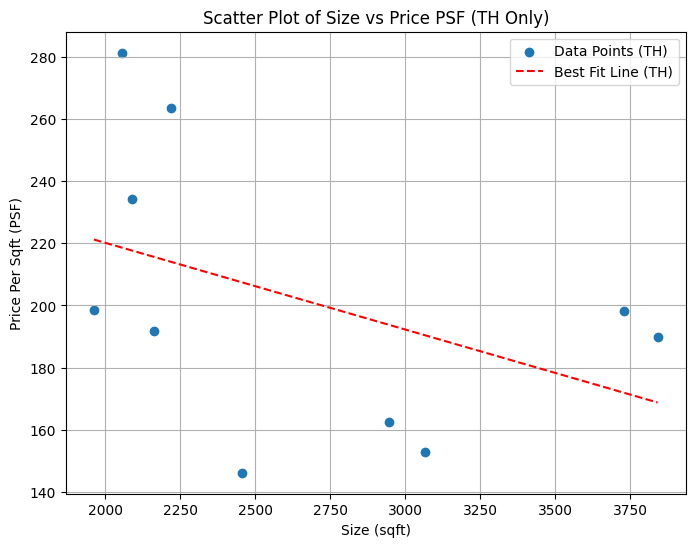

In [39]:
import matplotlib.pyplot as plt
import numpy as np

# Filter for only TH rows
df_th = df[df["Type"] == "TH"]

# Scatter plot for TH rows
plt.figure(figsize=(8, 6))
plt.scatter(df_th["Size"], df_th["Price PSF"], label='Data Points (TH)')

# Calculate and plot best fit line for TH rows (skip nulls)
x = df_th["Size"]
y = df_th["Price PSF"]
mask = (~x.isna()) & (~y.isna())
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
x_sorted = np.sort(x[mask])
plt.plot(x_sorted, p(x_sorted), "r--", label='Best Fit Line (TH)')

plt.xlabel("Size (sqft)")
plt.ylabel("Price Per Sqft (PSF)")
plt.title("Scatter Plot of Size vs Price PSF (TH Only)")
plt.grid(True)
plt.legend()
plt.show()
